# **Librerias e info**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# from google.colab import files
# uploaded = files.upload()

from google.colab import drive
#drive.mount('/content/drive')

# PARAMETROS

rnd_state = 42

In [ ]:
DATA_PATH = "supply_chain_order_fulfillment_delay_risk.csv"
df = pd.read_csv(DATA_PATH)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

# Opción 1: archivo en carpeta local (entrega)
LOCAL_PATH = "supply_chain_order_fulfillment_delay_risk.csv"

# Opción 2: Google Drive (tu entorno)
DRIVE_PATH = '/content/drive/MyDrive/ColabData/supply_chain_order_fulfillment_delay_risk.csv'

if os.path.exists(LOCAL_PATH):
    DATA_PATH = LOCAL_PATH
elif os.path.exists(DRIVE_PATH):
    DATA_PATH = DRIVE_PATH
else:
    raise FileNotFoundError("No se encontró el dataset en ninguna ruta conocida")

df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado desde: {DATA_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado desde: supply_chain_order_fulfillment_delay_risk.csv


# **EDA**

In [ ]:
print("Forma del dataset:", df.shape)

#Para mostrar todas la columnas uso el siguiente codigo, luego describe
pd.set_option("display.max_columns",None)

print("\nPrimeras 5 filas del dataset:")
df.head(10)

Forma del dataset: (2800, 11)

Primeras 5 filas del dataset:


KeyError: 'In'

,order_id,order_date,supplier_reliability_score,warehouse_inventory_level,order_quantity,shipping_distance_km,shipping_method,weather_condition,processing_time_hours,order_priority,delayed
0,1,2023-01-01 00:00:00,0.63,2869,253,1822.8,Sea,Fog,15.6,Low,1
1,2,2023-01-01 01:00:00,0.91,2406,370,876.1,Road,Fog,53.2,Low,0
2,3,2023-01-01 02:00:00,0.78,4665,198,134.2,Rail,Fog,62.2,Low,0
3,4,2023-01-01 03:00:00,0.89,1545,363,817.9,Sea,Storm,8.2,High,0
4,5,2023-01-01 04:00:00,0.99,511,454,984.3,Sea,Storm,46.5,High,1
5,6,2023-01-01 05:00:00,0.82,1270,44,101.9,Air,Fog,19.1,High,1
6,7,2023-01-01 06:00:00,0.80,3629,155,231.8,Road,Storm,45.5,Low,1
7,8,2023-01-01 07:00:00,0.63,4468,66,1964.5,Rail,Rain,47.9,Medium,0
8,9,2023-01-01 08:00:00,0.71,614,471,1710.2,Sea,Rain,3.3,Medium,0
9,10,2023-01-01 09:00:00,0.80,3312,276,328.6,Rail,Storm,5.6,Medium,0


In [ ]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   order_id                    2800 non-null   int64         
 1   order_date                  2800 non-null   datetime64[ns]
 2   supplier_reliability_score  2800 non-null   float64       
 3   warehouse_inventory_level   2800 non-null   int64         
 4   order_quantity              2800 non-null   int64         
 5   shipping_distance_km        2800 non-null   float64       
 6   shipping_method             2800 non-null   object        
 7   weather_condition           2800 non-null   object        
 8   processing_time_hours       2800 non-null   float64       
 9   order_priority              2800 non-null   object        
 10  delayed                     2800 non-null   int64         
 11  weather_group               2800 non-null   object      

KeyError: 'In'

,order_id,order_date,supplier_reliability_score,warehouse_inventory_level,order_quantity,shipping_distance_km,shipping_method,weather_condition,processing_time_hours,order_priority,delayed,weather_group,distance_group,distance_bin,shipping_group,stock_insuf,log_distance,log_processing_time,log_quantity,day_of_week,is_weekend,dow_sin,dow_cos
count,2800.000000,2800,2800.000000,2800.000000,2800.000000,2800.000000,2800,2800,2800.000000,2800,2800.000000,2800,2800,2800,2800,2800,2800.000000,2800.000000,2800.000000,2800.000000,2800,2800.000000,2800.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,4,NaN,3,NaN,2,4,2,2,2,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Road,Fog,NaN,Low,NaN,Adverso,muy_larga,más de 250 km,Terrestre,stock_sufic,NaN,NaN,NaN,NaN,no,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,723,746,NaN,942,NaN,2104,1425,2485,1427,2693,NaN,NaN,NaN,NaN,2008,NaN,NaN
mean,1400.500000,2023-02-28 07:30:00,0.796957,2493.010357,251.872500,1014.307714,NaN,NaN,35.841071,NaN,0.291429,NaN,NaN,NaN,NaN,NaN,6.638981,3.361383,5.230235,2.974286,NaN,0.010836,0.012204
min,1.000000,2023-01-01 00:00:00,0.600000,52.000000,1.000000,5.200000,NaN,NaN,1.100000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,1.824549,0.741937,0.693147,0.000000,NaN,-0.974928,-0.900969
25%,700.750000,2023-01-30 03:45:00,0.700000,1309.000000,128.000000,532.950000,NaN,NaN,17.975000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,6.280302,2.943120,4.859812,1.000000,NaN,-0.781831,-0.900969
50%,1400.500000,2023-02-28 07:30:00,0.790000,2459.000000,253.000000,1016.100000,NaN,NaN,35.400000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,6.924711,3.594569,5.537334,3.000000,NaN,0.000000,-0.222521
75%,2100.250000,2023-03-29 11:15:00,0.900000,3688.000000,377.000000,1508.825000,NaN,NaN,53.400000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,7.319749,3.996364,5.934894,5.000000,NaN,0.781831,0.623490
max,2800.000000,2023-04-27 15:00:00,1.000000,4996.000000,499.000000,1998.600000,NaN,NaN,72.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,7.600702,4.290459,6.214608,6.000000,NaN,0.974928,1.000000


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
supplier_reliability_score,0
warehouse_inventory_level,0
order_quantity,0
shipping_distance_km,0
shipping_method,0
weather_condition,0
processing_time_hours,0
order_priority,0


In [ ]:
duplicates = df[df.duplicated()]
print("Duplicate Rows:")

Duplicate Rows:


In [ ]:
df.drop('order_id', axis=1, inplace=True)

# **Feature Engineering**

In [ ]:
df['stock_insuf'] = np.where(df['warehouse_inventory_level'] < df['order_quantity'], 1, 0)
df.head()

KeyError: 'In'

,order_date,supplier_reliability_score,warehouse_inventory_level,order_quantity,shipping_distance_km,shipping_method,weather_condition,processing_time_hours,order_priority,delayed,stock_insuf
0,2023-01-01 00:00:00,0.63,2869,253,1822.8,Sea,Fog,15.6,Low,1,0
1,2023-01-01 01:00:00,0.91,2406,370,876.1,Road,Fog,53.2,Low,0,0
2,2023-01-01 02:00:00,0.78,4665,198,134.2,Rail,Fog,62.2,Low,0,0
3,2023-01-01 03:00:00,0.89,1545,363,817.9,Sea,Storm,8.2,High,0,0
4,2023-01-01 04:00:00,0.99,511,454,984.3,Sea,Storm,46.5,High,1,0


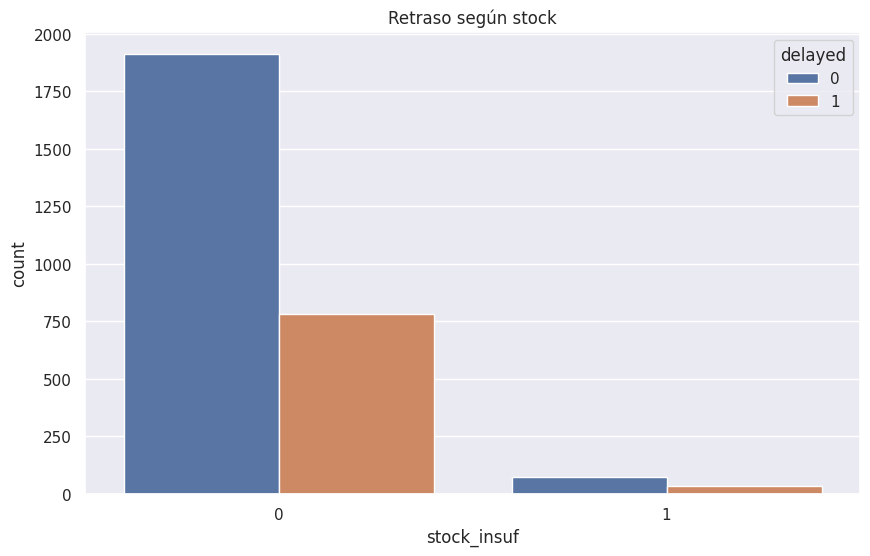

In [ ]:
# Gráfico para ver el Churn según el tipo de contrato
plt.figure(figsize=(10,6))
sns.countplot(x='stock_insuf', hue='delayed', data=df)
plt.title('Retraso según stock')
plt.show()

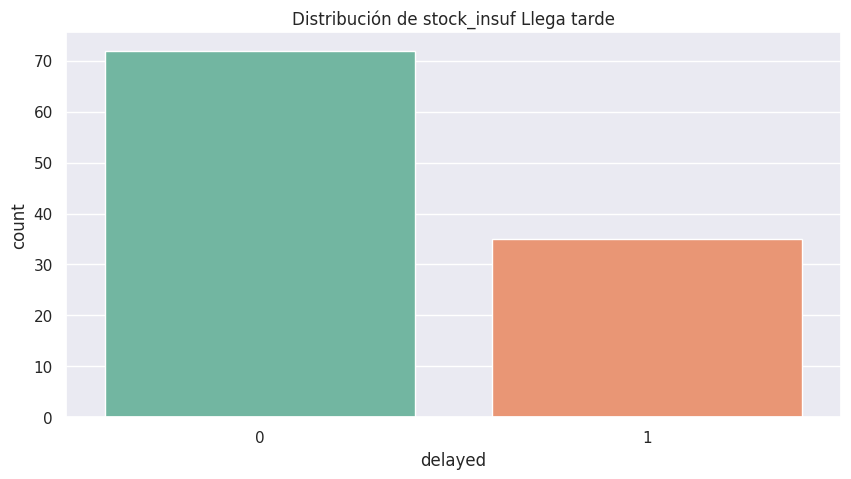

In [ ]:
#Análisis Univariado
plt.figure(figsize=(10, 5))
sns.countplot(x='delayed', data=df[df["stock_insuf"] == 1], palette='Set2')
plt.title("Distribución de stock_insuf Llega tarde")
plt.show()

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day
df['dayofweek'] = df['order_date'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['isweekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
df['hour'] = df['order_date'].dt.hour
df.head()

KeyError: 'In'

,order_date,supplier_reliability_score,warehouse_inventory_level,order_quantity,shipping_distance_km,shipping_method,weather_condition,processing_time_hours,order_priority,delayed,stock_insuf,month,day,dayofweek,isweekend,hour
0,2023-01-01 00:00:00,0.63,2869,253,1822.8,Sea,Fog,15.6,Low,1,0,1,1,6,1,0
1,2023-01-01 01:00:00,0.91,2406,370,876.1,Road,Fog,53.2,Low,0,0,1,1,6,1,1
2,2023-01-01 02:00:00,0.78,4665,198,134.2,Rail,Fog,62.2,Low,0,0,1,1,6,1,2
3,2023-01-01 03:00:00,0.89,1545,363,817.9,Sea,Storm,8.2,High,0,0,1,1,6,1,3
4,2023-01-01 04:00:00,0.99,511,454,984.3,Sea,Storm,46.5,High,1,0,1,1,6,1,4


# **KPIs**

Porcentaje de pedidos no retrasados: 70.86%


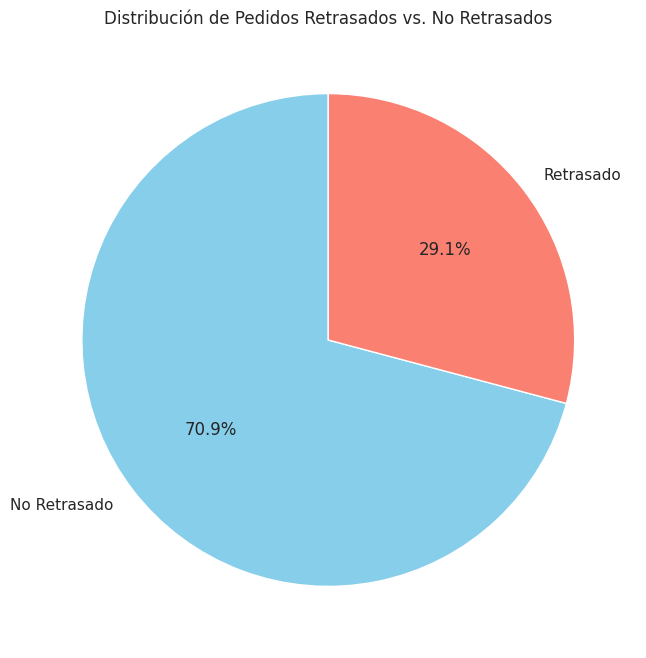

In [ ]:
non_delayed_percentage = 1 - (df['delayed'].sum() / len(df))
print(f"Porcentaje de pedidos no retrasados: {non_delayed_percentage:.2%}")

# Crear el gráfico de torta
# Calcular el conteo de pedidos retrasados y no retrasados
delayed_counts = df['delayed'].value_counts()

# Etiquetas para el gráfico de torta
labels = ['No Retrasado', 'Retrasado']

# Crear el gráfico de torta
plt.figure(figsize=(8, 8))
plt.pie(delayed_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Distribución de Pedidos Retrasados vs. No Retrasados')
plt.show()

# **Distribuciones**

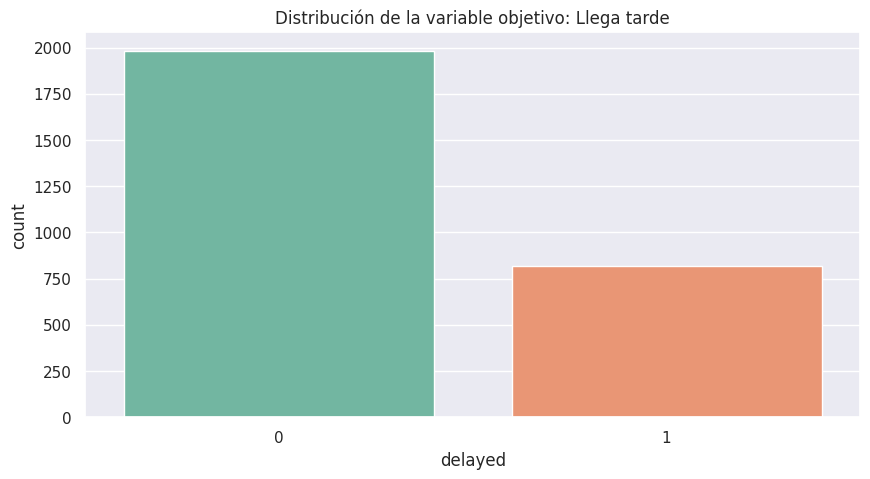


Proporción de envios tardios:
delayed
0    0.708571
1    0.291429
Name: proportion, dtype: float64


In [ ]:
#Análisis Univariado
plt.figure(figsize=(10, 5))
sns.countplot(x='delayed', data=df, palette='Set2')
plt.title("Distribución de la variable objetivo: Llega tarde")
plt.show()

print("\nProporción de envios tardios:")
print(df['delayed'].value_counts(normalize=True))

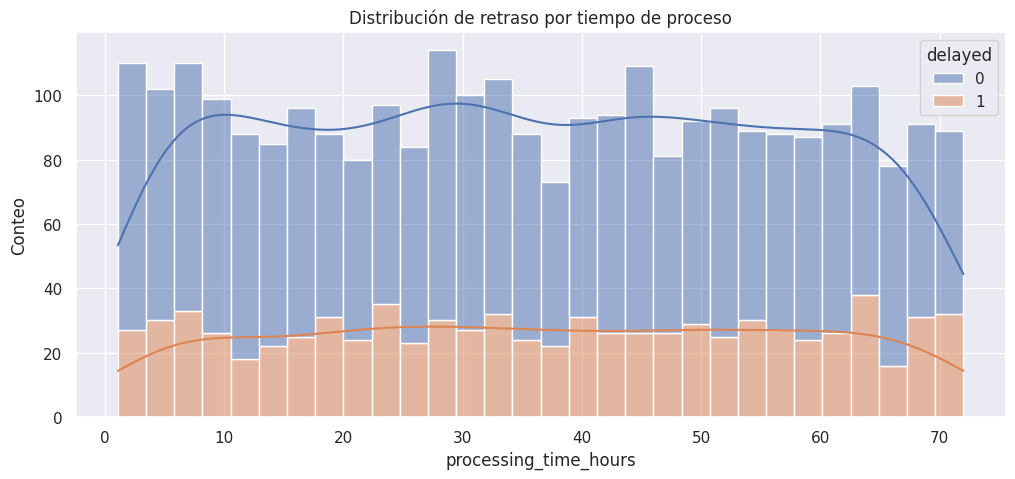

In [ ]:
# Distribución de Abandono por tarifa
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='processing_time_hours', hue='delayed', multiple='stack', kde=True, bins=30)
plt.title('Distribución de retraso por tiempo de proceso')
plt.xlabel('processing_time_hours')
plt.ylabel('Conteo')
plt.show()


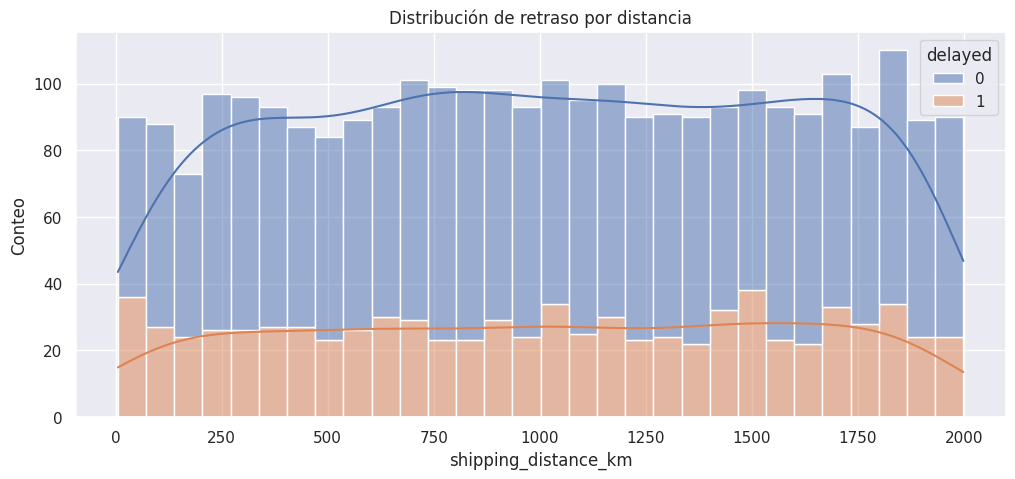

In [ ]:
# Distribución de Abandono por tarifa
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='shipping_distance_km', hue='delayed', multiple='stack', kde=True, bins=30)
plt.title('Distribución de retraso por distancia')
plt.xlabel('shipping_distance_km')
plt.ylabel('Conteo')
plt.show()


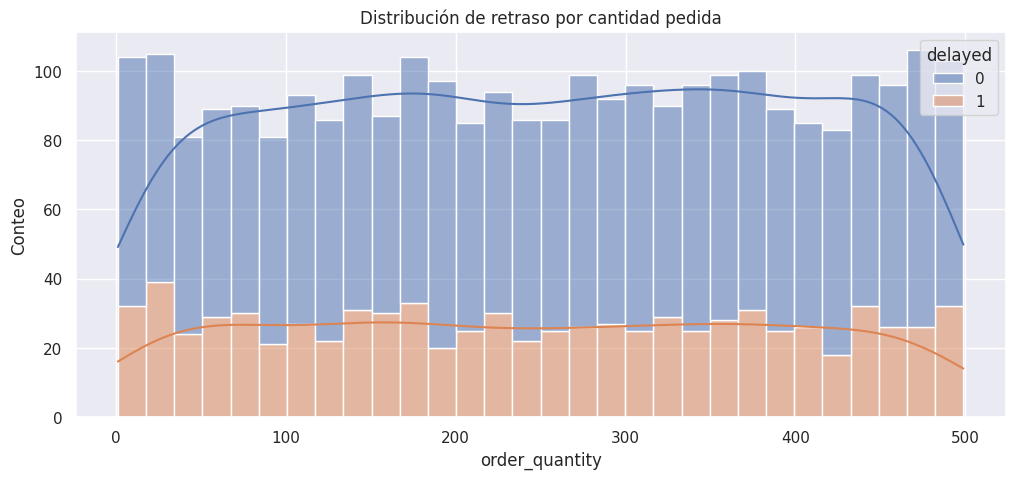

In [ ]:
# Distribución de Abandono por tarifa
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='order_quantity', hue='delayed', multiple='stack', kde=True, bins=30)
plt.title('Distribución de retraso por cantidad pedida')
plt.xlabel('order_quantity')
plt.ylabel('Conteo')
plt.show()


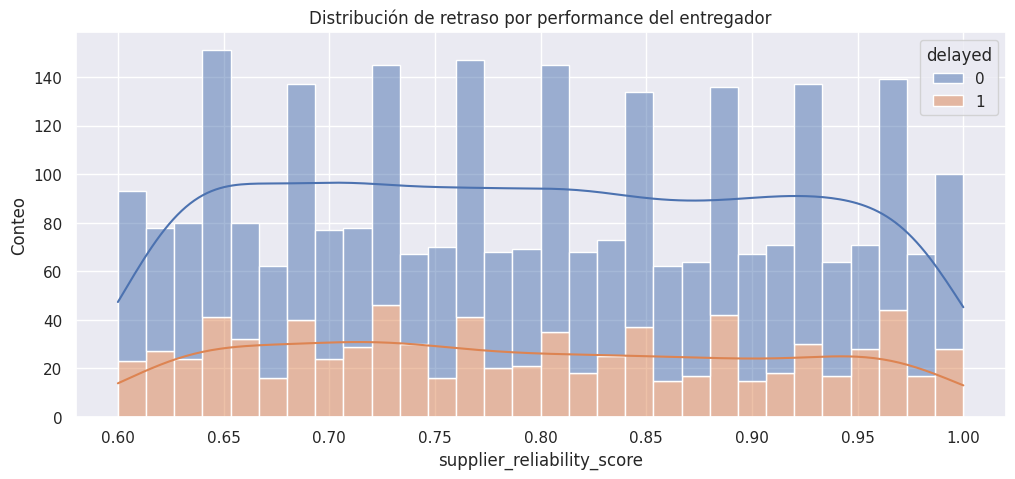

In [ ]:
# Distribución de Abandono por tarifa
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='supplier_reliability_score', hue='delayed', multiple='stack', kde=True, bins=30)
plt.title('Distribución de retraso por performance del entregador')
plt.xlabel('supplier_reliability_score')
plt.ylabel('Conteo')
plt.show()

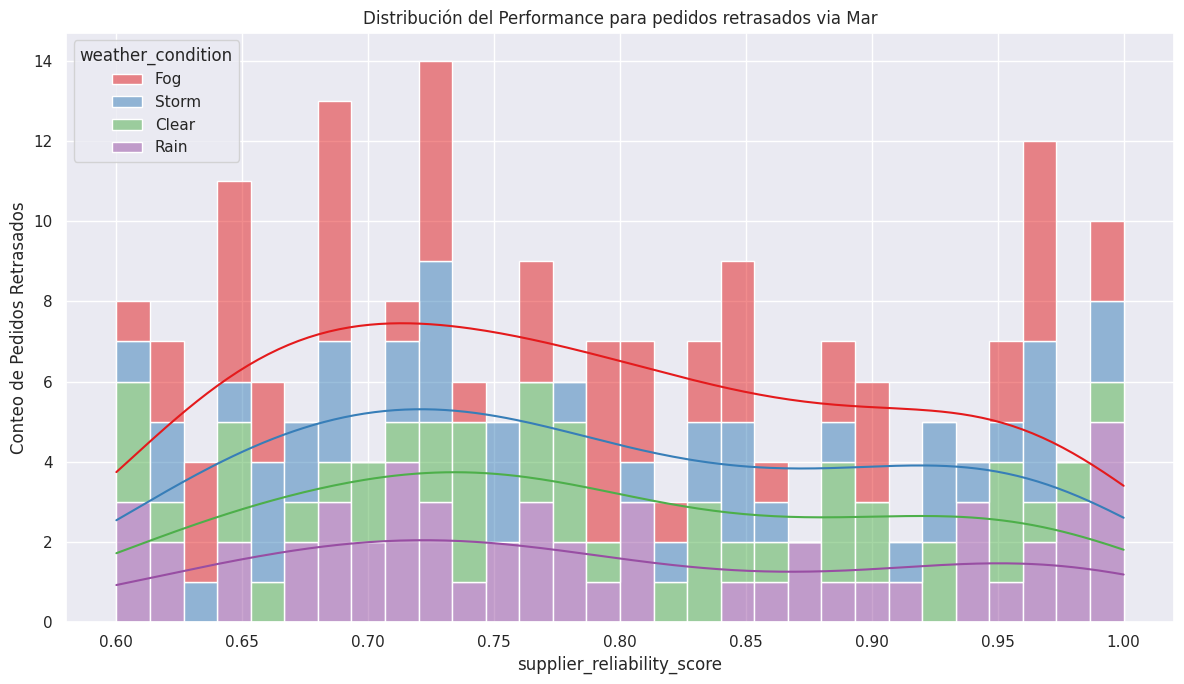

In [ ]:
plt.figure(figsize=(12, 7))
clear_delayed_df = df[(df['delayed']==1) & (df['shipping_method']=='Sea')]
sns.histplot(
    data=clear_delayed_df,
    x='supplier_reliability_score',
    hue='weather_condition',
    multiple='stack',
    kde=True,
    bins=30,
    palette='Set1' # Using Set1 for distinct colors
)
plt.title('Distribución del Performance para pedidos retrasados via Mar')
plt.xlabel('supplier_reliability_score')
plt.ylabel('Conteo de Pedidos Retrasados')
plt.tight_layout()
plt.show()

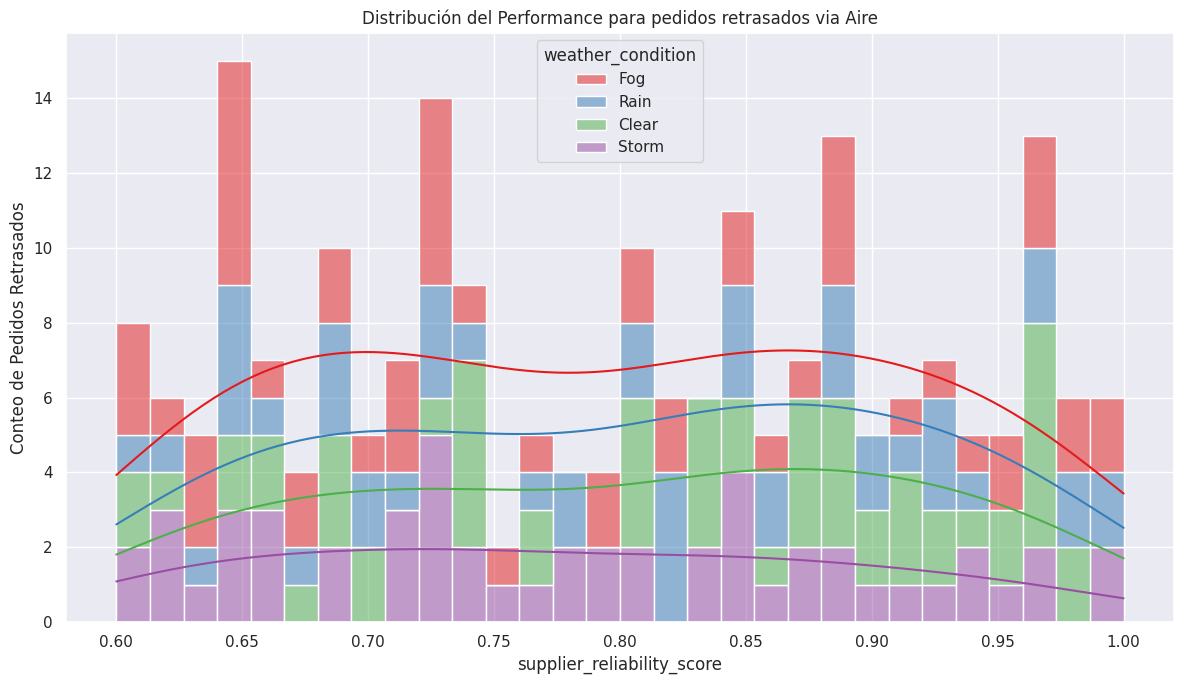

In [ ]:
plt.figure(figsize=(12, 7))
clear_delayed_df = df[(df['delayed']==1) & (df['shipping_method']=='Air')]
sns.histplot(
    data=clear_delayed_df,
    x='supplier_reliability_score',
    hue='weather_condition',
    multiple='stack',
    kde=True,
    bins=30,
    palette='Set1' # Using Set1 for distinct colors
)
plt.title('Distribución del Performance para pedidos retrasados via Aire')
plt.xlabel('supplier_reliability_score')
plt.ylabel('Conteo de Pedidos Retrasados')
plt.tight_layout()
plt.show()

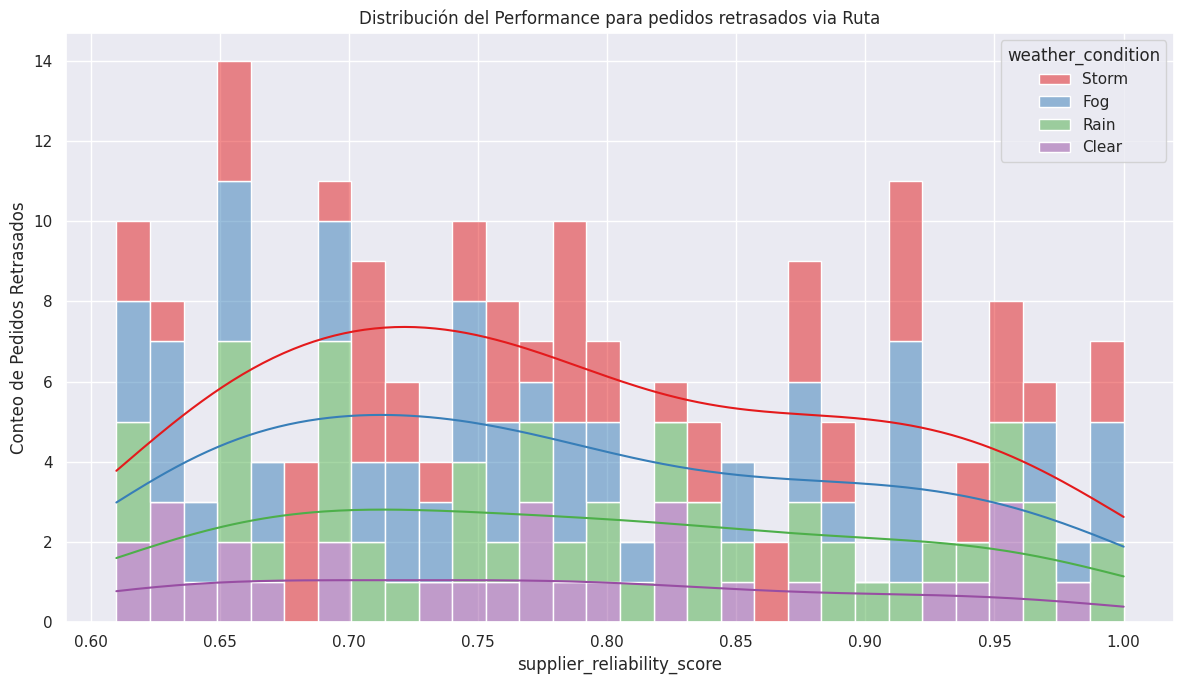

In [ ]:
plt.figure(figsize=(12, 7))
clear_delayed_df = df[(df['delayed']==1) & (df['shipping_method']=='Road')]
sns.histplot(
    data=clear_delayed_df,
    x='supplier_reliability_score',
    hue='weather_condition',
    multiple='stack',
    kde=True,
    bins=30,
    palette='Set1' # Using Set1 for distinct colors
)
plt.title('Distribución del Performance para pedidos retrasados via Ruta')
plt.xlabel('supplier_reliability_score')
plt.ylabel('Conteo de Pedidos Retrasados')
plt.tight_layout()
plt.show()

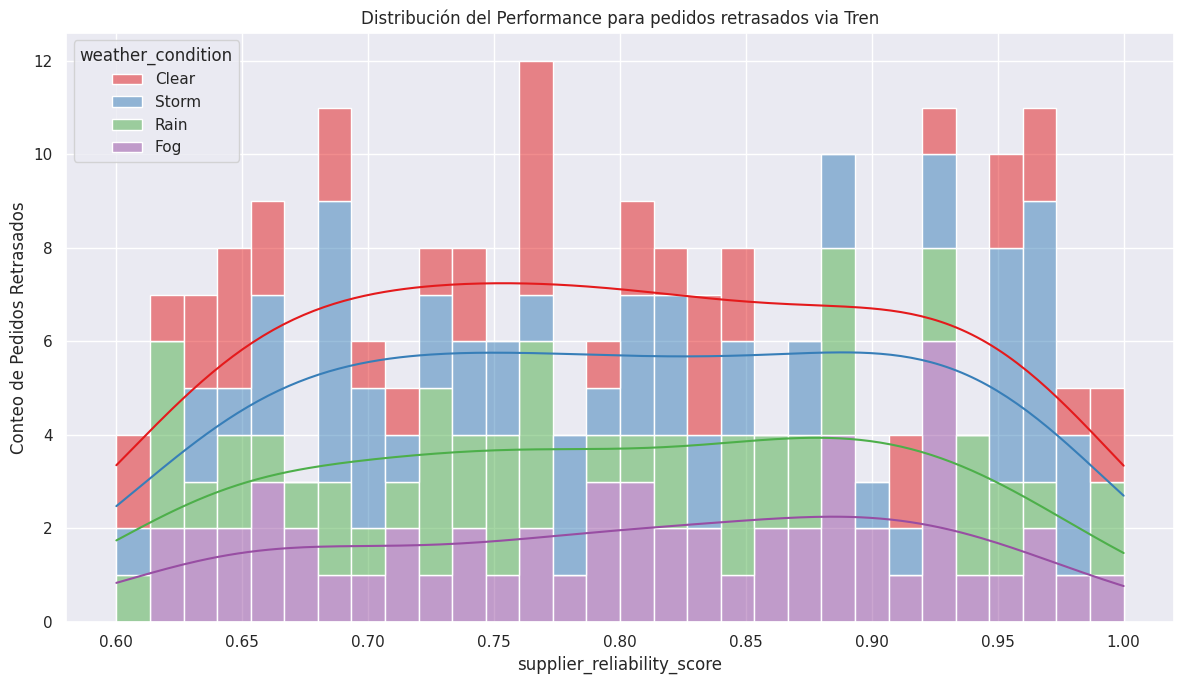

In [ ]:
plt.figure(figsize=(12, 7))
clear_delayed_df = df[(df['delayed']==1) & (df['shipping_method']=='Rail')]
sns.histplot(
    data=clear_delayed_df,
    x='supplier_reliability_score',
    hue='weather_condition',
    multiple='stack',
    kde=True,
    bins=30,
    palette='Set1' # Using Set1 for distinct colors
)
plt.title('Distribución del Performance para pedidos retrasados via Tren')
plt.xlabel('supplier_reliability_score')
plt.ylabel('Conteo de Pedidos Retrasados')
plt.tight_layout()
plt.show()

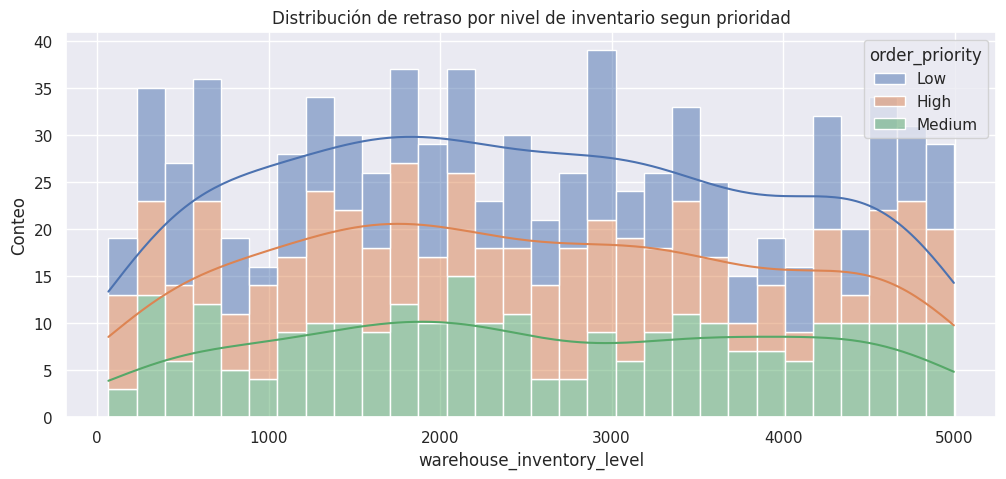

In [ ]:
# Distribución de Abandono por tarifa
plt.figure(figsize=(12, 5))
sns.histplot(data=df[df["delayed"]==1], x='warehouse_inventory_level', hue='order_priority', multiple='stack', kde=True, bins=30)
plt.title('Distribución de retraso por nivel de inventario segun prioridad')
plt.xlabel('warehouse_inventory_level')
plt.ylabel('Conteo')
plt.show()

# Notar que en la primer columna los high son significativamente mayores a low/medium, luego se normaliza

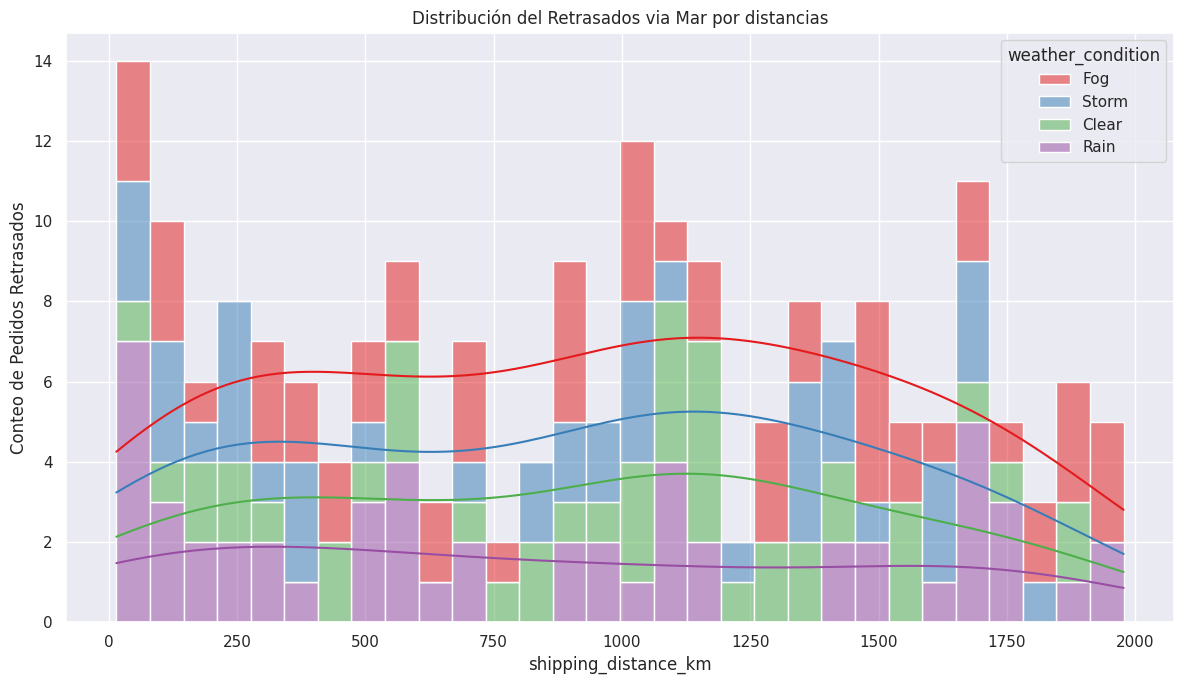

In [ ]:
plt.figure(figsize=(12, 7))
clear_delayed_df = df[(df['delayed']==1) & (df['shipping_method']=='Sea')]
sns.histplot(
    data=clear_delayed_df,
    x='shipping_distance_km',
    hue='weather_condition',
    multiple='stack',
    kde=True,
    bins=30,
    palette='Set1' # Using Set1 for distinct colors
)
plt.title('Distribución del Retrasados via Mar por distancias')
plt.xlabel('shipping_distance_km')
plt.ylabel('Conteo de Pedidos Retrasados')
plt.tight_layout()
plt.show()

#Notar que a cortas distancias hay muchos retrasos

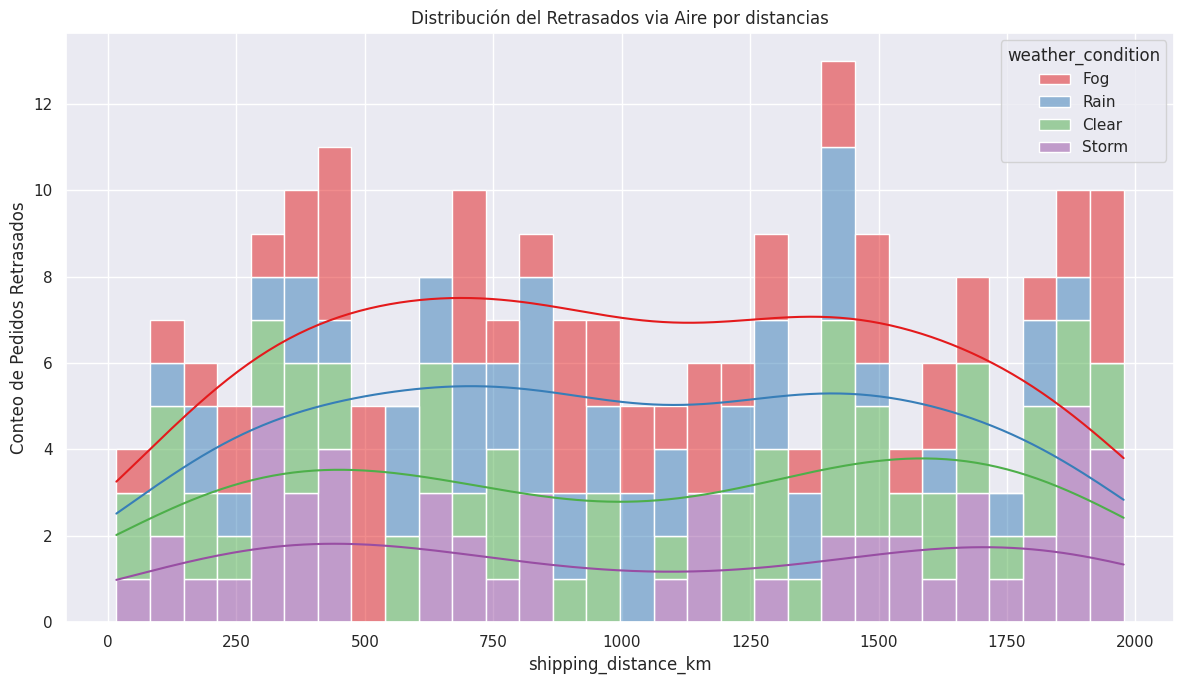

In [ ]:
plt.figure(figsize=(12, 7))
clear_delayed_df = df[(df['delayed']==1) & (df['shipping_method']=='Air')]
sns.histplot(
    data=clear_delayed_df,
    x='shipping_distance_km',
    hue='weather_condition',
    multiple='stack',
    kde=True,
    bins=30,
    palette='Set1' # Using Set1 for distinct colors
)
plt.title('Distribución del Retrasados via Aire por distancias')
plt.xlabel('shipping_distance_km')
plt.ylabel('Conteo de Pedidos Retrasados')
plt.tight_layout()
plt.show()

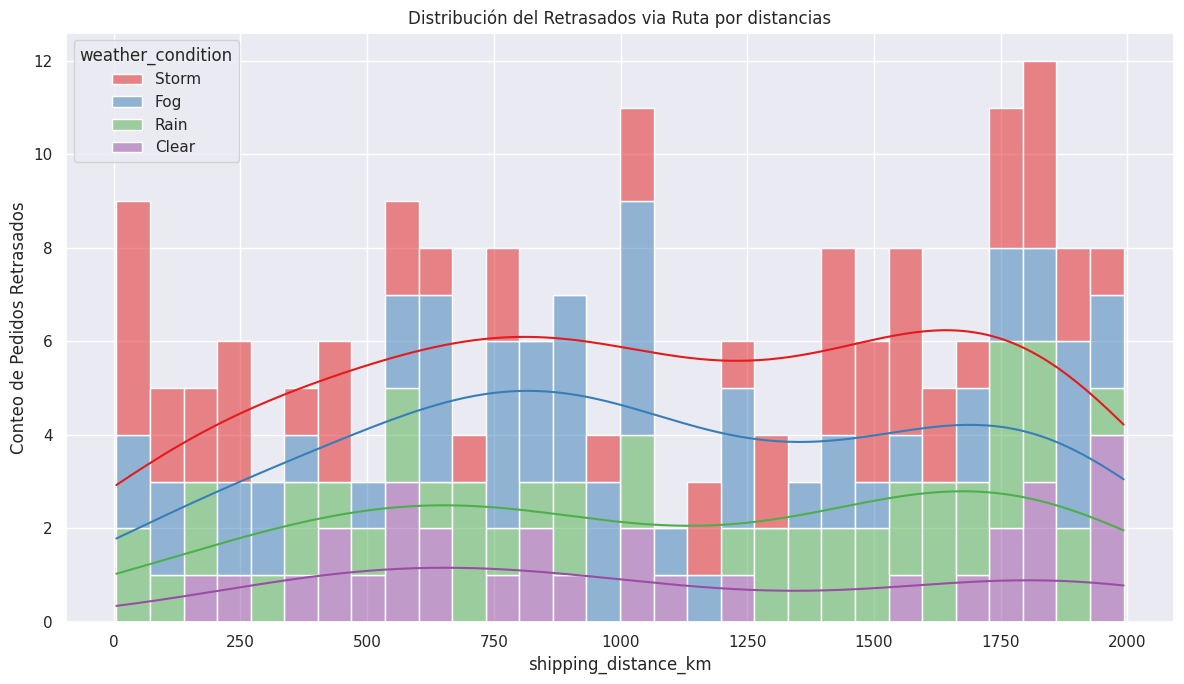

In [ ]:
plt.figure(figsize=(12, 7))
clear_delayed_df = df[(df['delayed']==1) & (df['shipping_method']=='Road')]
sns.histplot(
    data=clear_delayed_df,
    x='shipping_distance_km',
    hue='weather_condition',
    multiple='stack',
    kde=True,
    bins=30,
    palette='Set1' # Using Set1 for distinct colors
)
plt.title('Distribución del Retrasados via Ruta por distancias')
plt.xlabel('shipping_distance_km')
plt.ylabel('Conteo de Pedidos Retrasados')
plt.tight_layout()
plt.show()

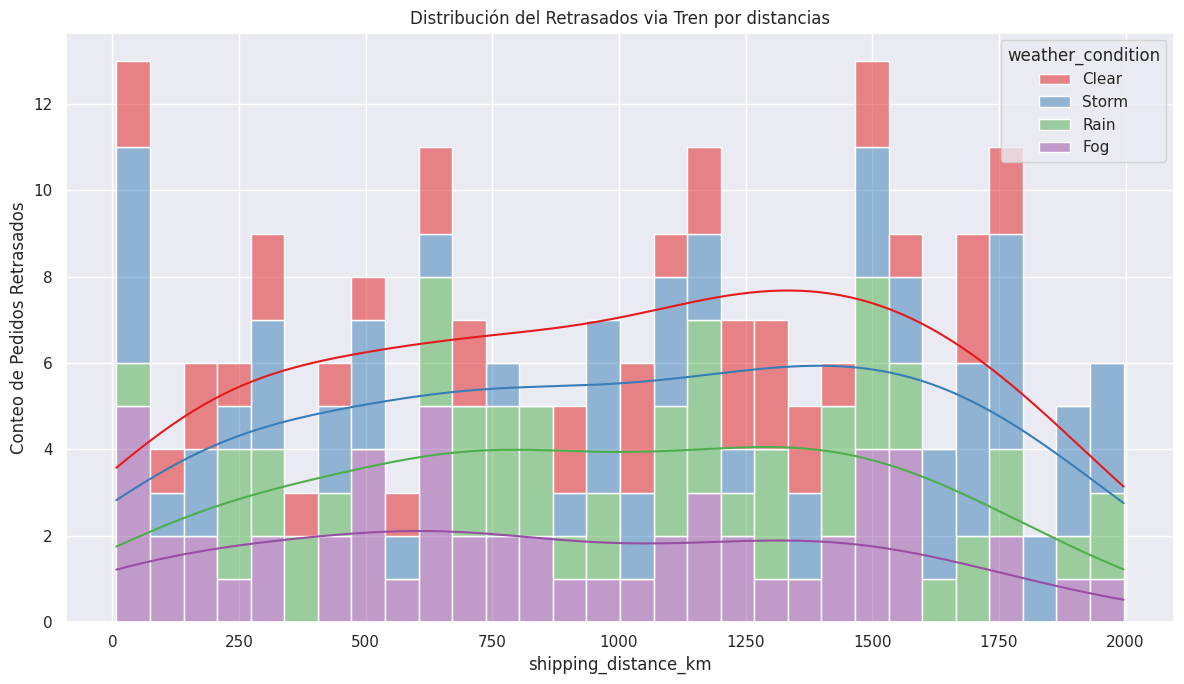

In [ ]:
plt.figure(figsize=(12, 7))
clear_delayed_df = df[(df['delayed']==1) & (df['shipping_method']=='Rail')]
sns.histplot(
    data=clear_delayed_df,
    x='shipping_distance_km',
    hue='weather_condition',
    multiple='stack',
    kde=True,
    bins=30,
    palette='Set1' # Using Set1 for distinct colors
)
plt.title('Distribución del Retrasados via Tren por distancias')
plt.xlabel('shipping_distance_km')
plt.ylabel('Conteo de Pedidos Retrasados')
plt.tight_layout()
plt.show()

# **Matriz de correlaciones**

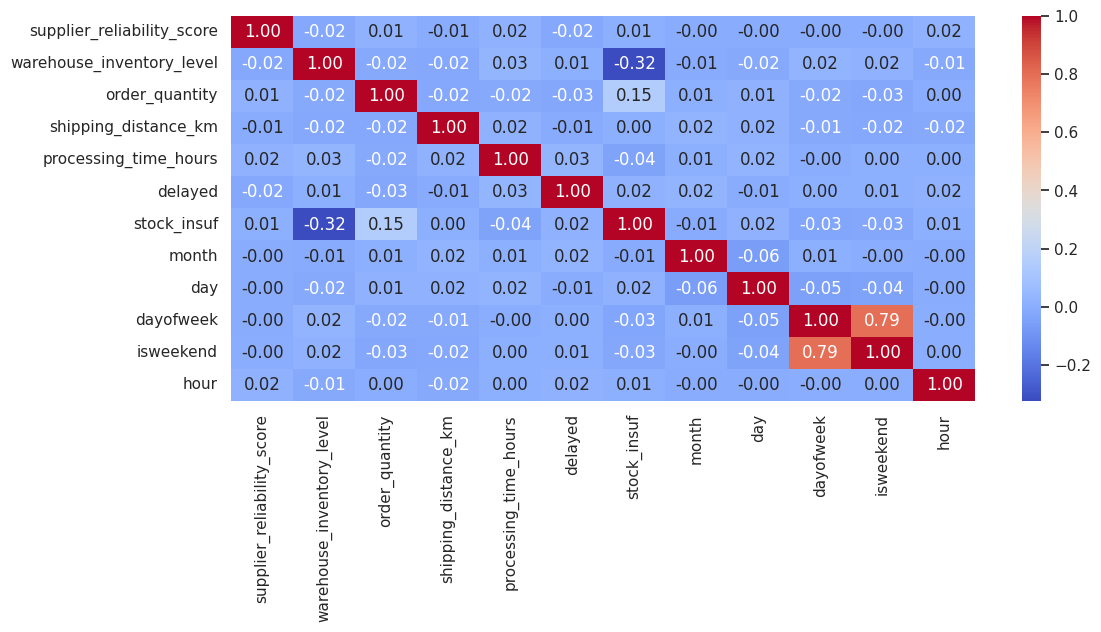

In [ ]:
# Cálculo de la matriz de correlación:
# Seleccionar solo las columnas numéricas
numeric_df = df.select_dtypes(include=['number'])

# Matriz de correlación
corr_matrix = numeric_df.corr()

# Mapa de calor
plt.figure(figsize=(12,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

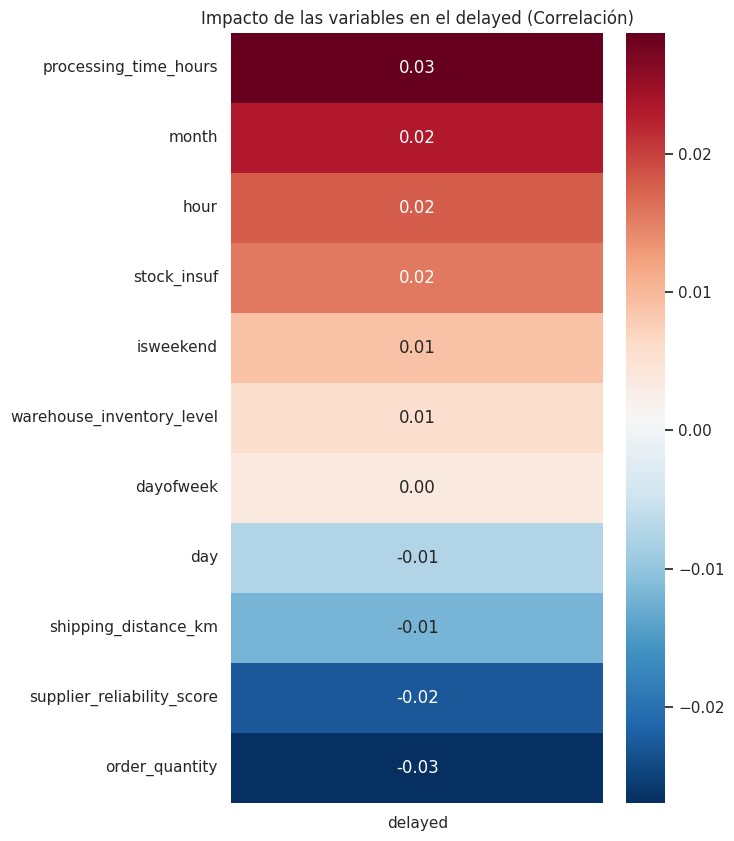

In [ ]:
# 2. Seleccionar solo la columna de correlación con 'Churn'
# Excluimos la correlación de 'Churn' consigo misma
delayed_corr = corr_matrix[['delayed']].drop('delayed').sort_values(by='delayed', ascending=False)

# 3. Graficar el mapa de calor de las correlaciones con Churn
plt.figure(figsize=(6, 10))
sns.heatmap(delayed_corr, annot=True, cmap='RdBu_r', cbar=True, fmt=".2f")

plt.title('Impacto de las variables en el delayed (Correlación)')
plt.show()

# **Outliers**

## **Univariado**

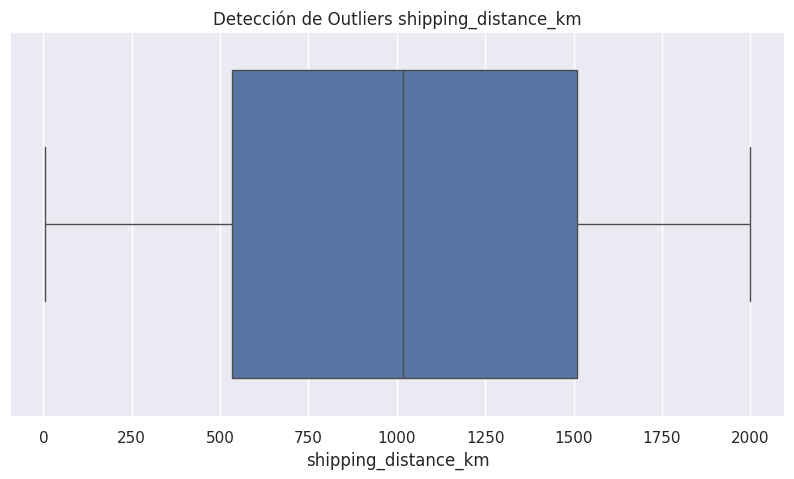

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['shipping_distance_km'])
plt.title("Detección de Outliers shipping_distance_km")
plt.show()

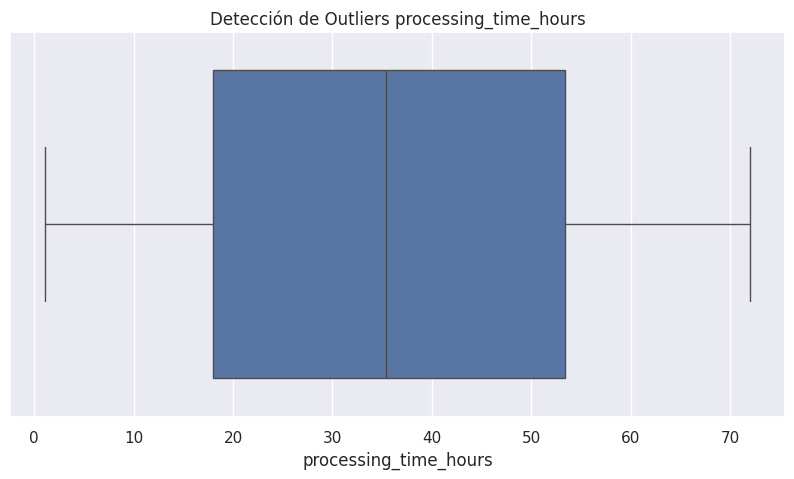

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['processing_time_hours'])
plt.title("Detección de Outliers processing_time_hours")
plt.show()

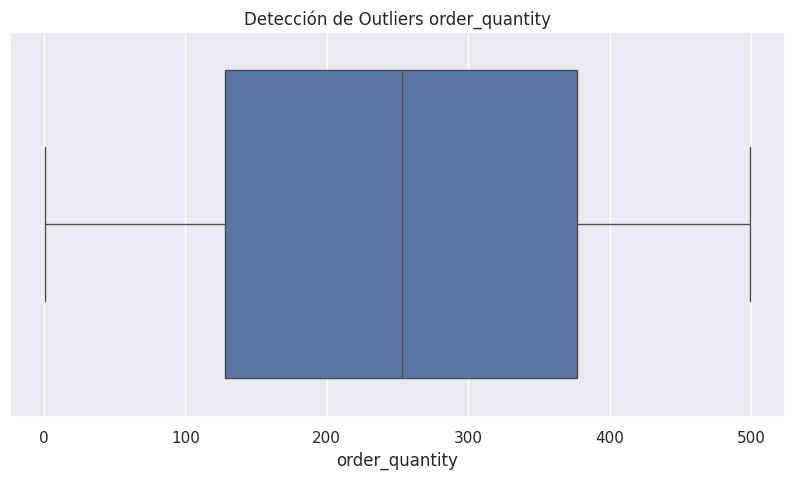

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['order_quantity'])
plt.title("Detección de Outliers order_quantity")
plt.show()

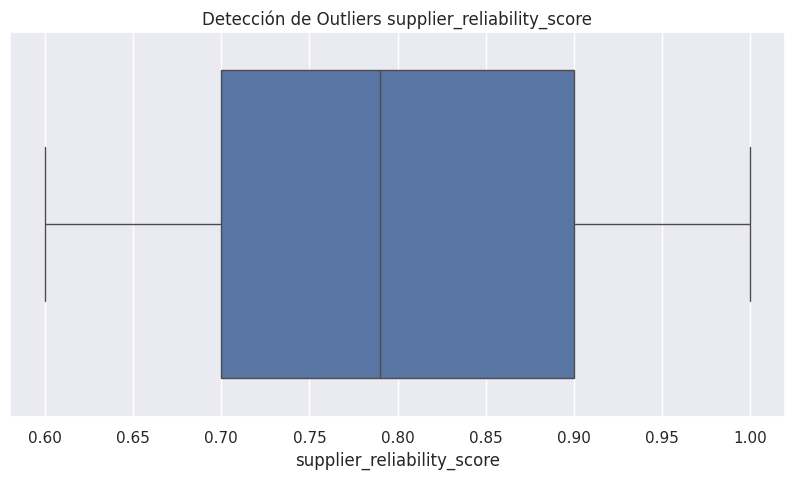

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['supplier_reliability_score'])
plt.title("Detección de Outliers supplier_reliability_score")
plt.show()

## **Bi-Variado**

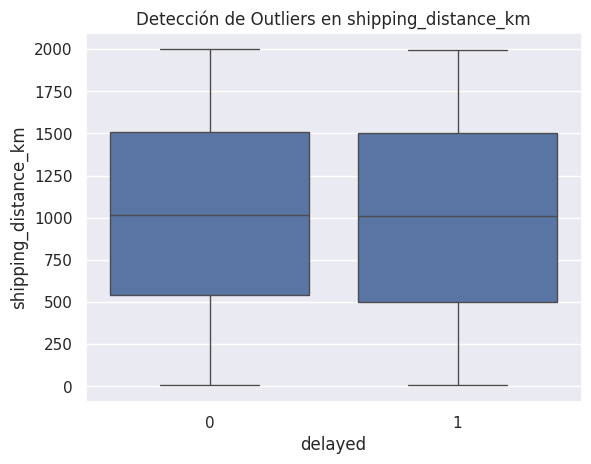

In [ ]:
# Para ver si la antigüedad influye en la fuga
sns.boxplot(x='delayed', y='shipping_distance_km', data=df)
plt.title("Detección de Outliers en shipping_distance_km")
plt.show()

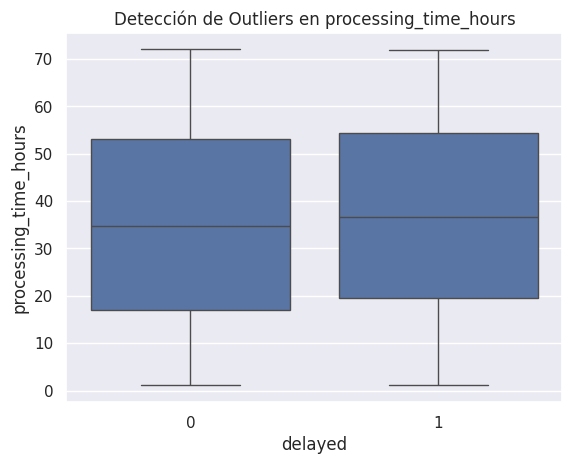

In [ ]:
# Para ver si la antigüedad influye en la fuga
sns.boxplot(x='delayed', y='processing_time_hours', data=df)
plt.title("Detección de Outliers en processing_time_hours")
plt.show()

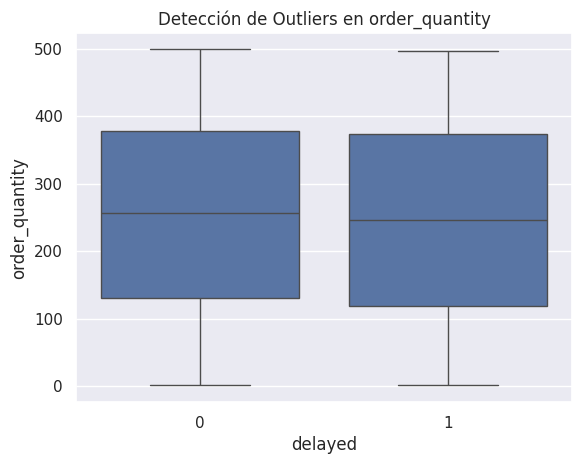

In [ ]:
# Para ver si la antigüedad influye en la fuga
sns.boxplot(x='delayed', y='order_quantity', data=df)
plt.title("Detección de Outliers en order_quantity")
plt.show()

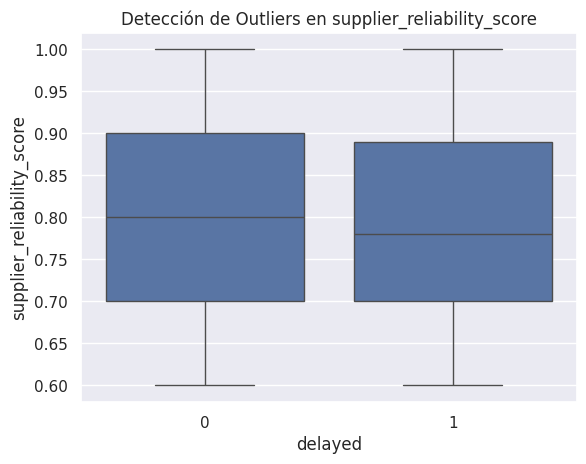

In [ ]:
# Para ver si la antigüedad influye en la fuga
sns.boxplot(x='delayed', y='supplier_reliability_score', data=df)
plt.title("Detección de Outliers en supplier_reliability_score")
plt.show()

# **Analisis por categoria**

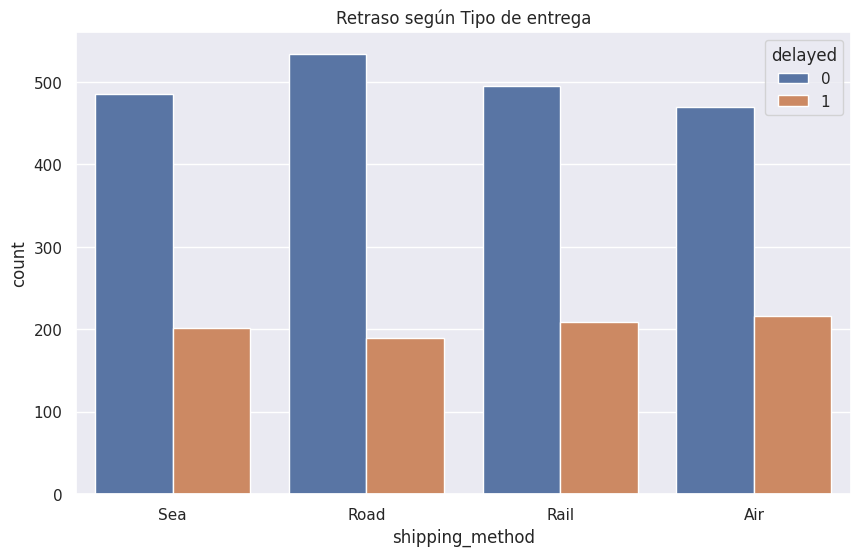

In [ ]:
# Gráfico para ver el Churn según el tipo de contrato
plt.figure(figsize=(10,6))
sns.countplot(x='shipping_method', hue='delayed', data=df)
plt.title('Retraso según Tipo de entrega')
plt.show()

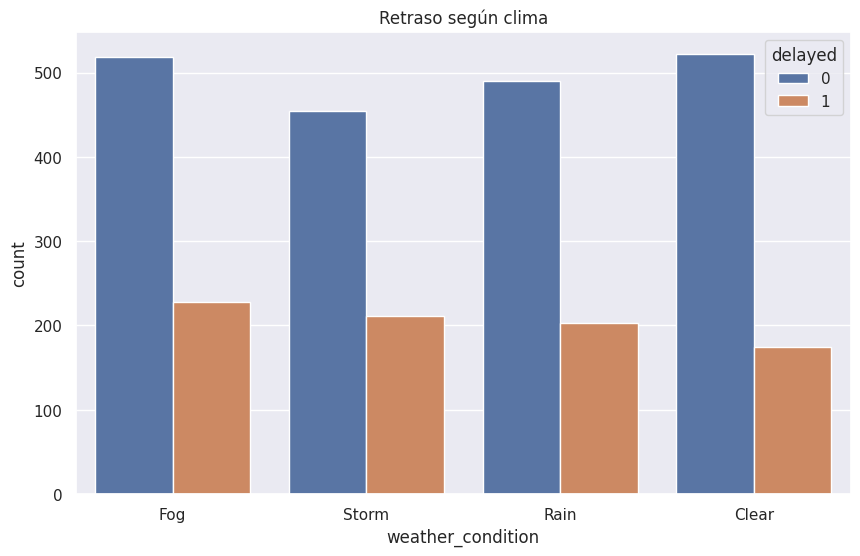

In [ ]:
# Gráfico para ver el Churn según el tipo de contrato
plt.figure(figsize=(10,6))
sns.countplot(x='weather_condition', hue='delayed', data=df)
plt.title('Retraso según clima')
plt.show()

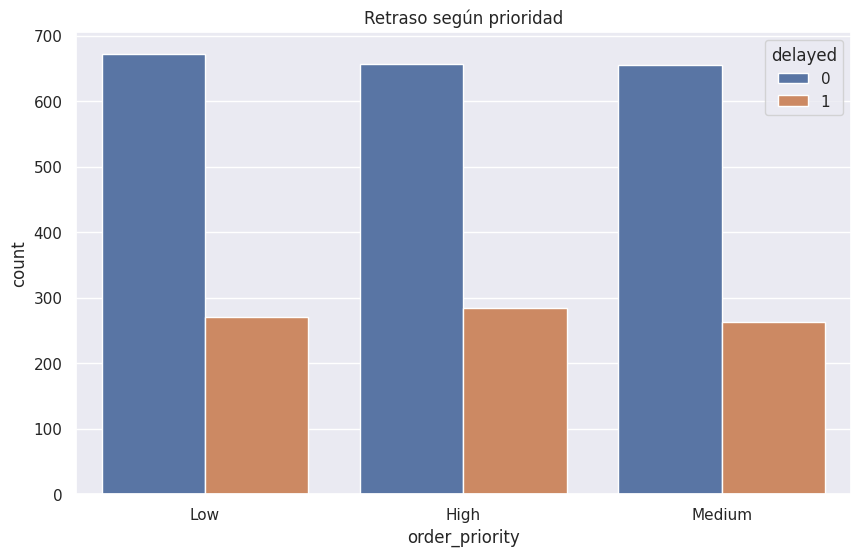

In [ ]:
# Gráfico para ver el Churn según el tipo de contrato
plt.figure(figsize=(10,6))
sns.countplot(x='order_priority', hue='delayed', data=df)
plt.title('Retraso según prioridad')
plt.show()

<Figure size 1500x700 with 0 Axes>

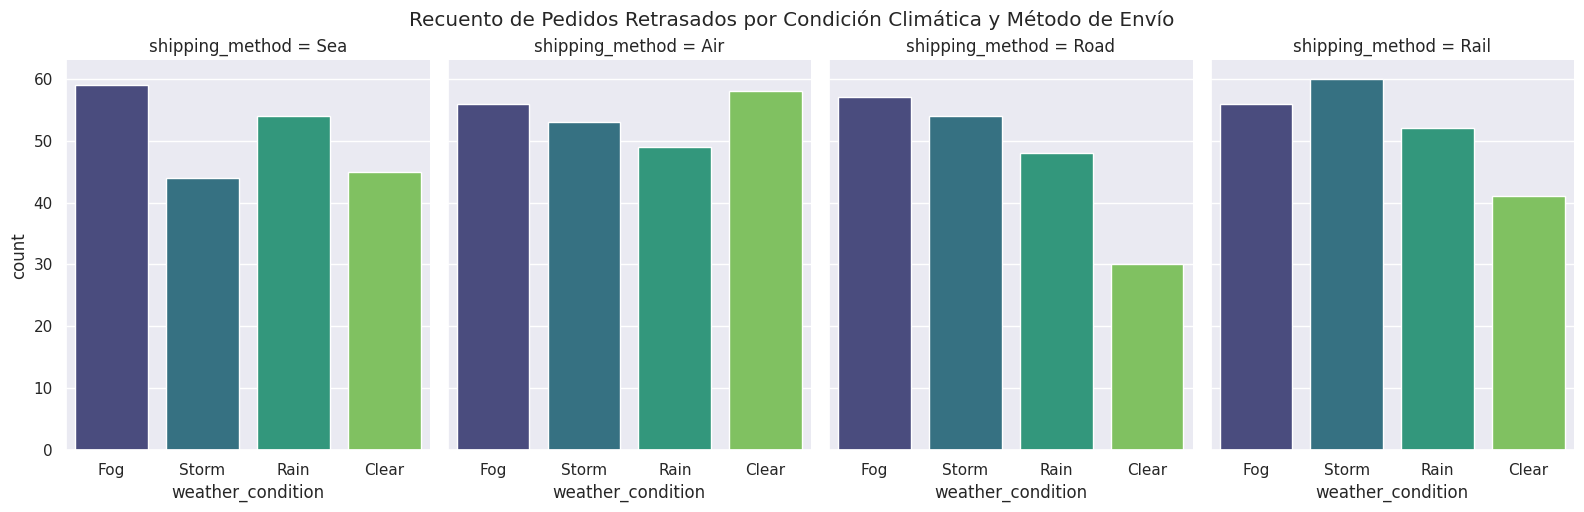

In [ ]:
plt.figure(figsize=(15, 7))
sns.catplot(x='weather_condition', col='shipping_method', data=df[df['delayed']==1], kind='count', palette='viridis', height=5, aspect=0.8)
plt.suptitle('Recuento de Pedidos Retrasados por Condición Climática y Método de Envío', y=1.02) # Ajusta el título para que no se superponga
plt.show()

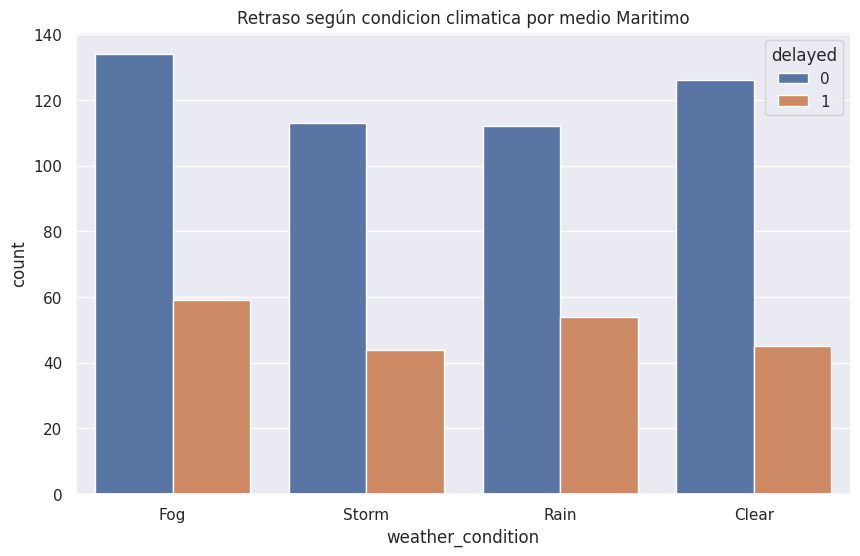

In [ ]:
# Gráfico para ver el Churn según el tipo de contrato
plt.figure(figsize=(10,6))
sns.countplot(x='weather_condition', hue='delayed', data=df[df['shipping_method']=="Sea"])
plt.title('Retraso según condicion climatica por medio Maritimo')
plt.show()

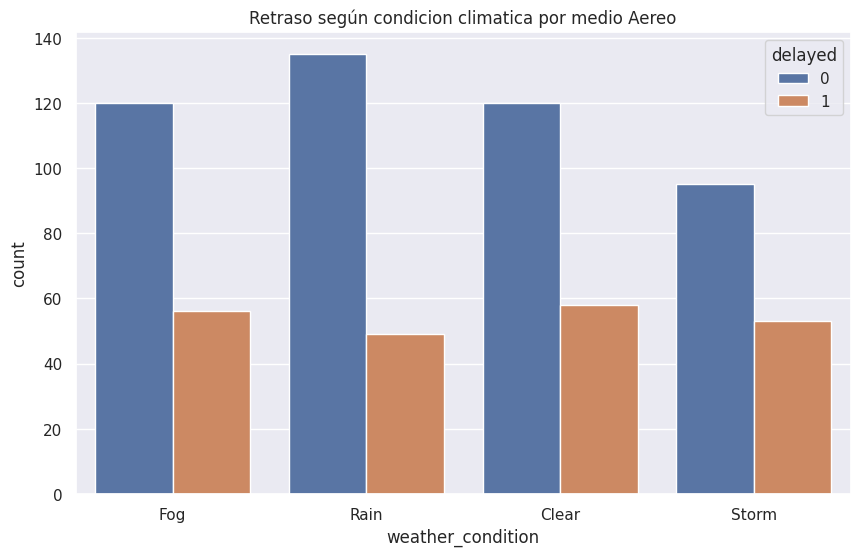

In [ ]:
# Gráfico para ver el Churn según el tipo de contrato
plt.figure(figsize=(10,6))
sns.countplot(x='weather_condition', hue='delayed', data=df[df['shipping_method']=="Air"])
plt.title('Retraso según condicion climatica por medio Aereo')
plt.show()

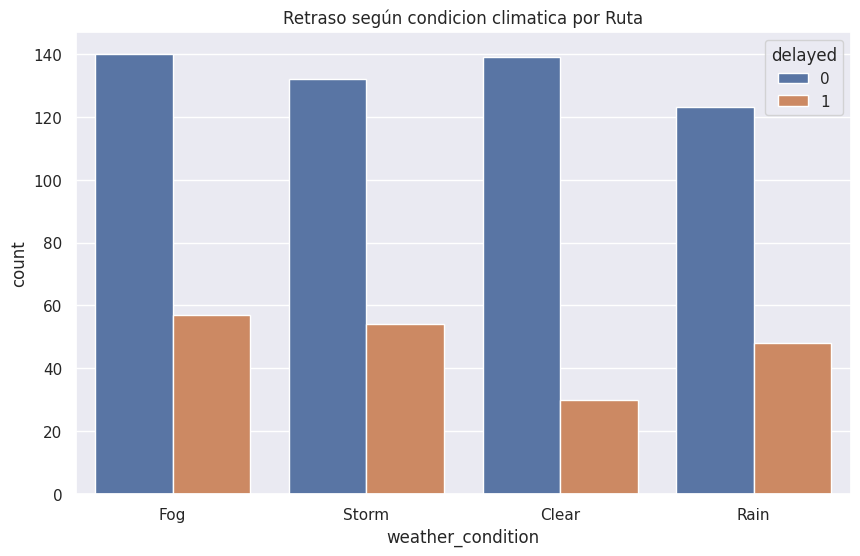

In [ ]:
# Gráfico para ver el Churn según el tipo de contrato
plt.figure(figsize=(10,6))
sns.countplot(x='weather_condition', hue='delayed', data=df[df['shipping_method']=="Road"])
plt.title('Retraso según condicion climatica por Ruta')
plt.show()

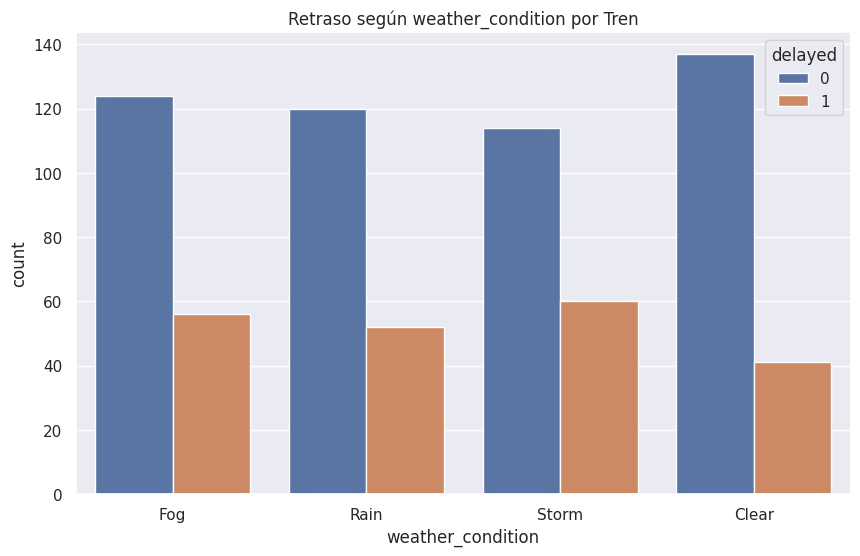

In [ ]:
# Gráfico para ver el Churn según el tipo de contrato
plt.figure(figsize=(10,6))
sns.countplot(x='weather_condition', hue='delayed', data=df[df['shipping_method']=="Rail"])
plt.title('Retraso según weather_condition por Tren')
plt.show()

# **RESET POST EDA**



In [ ]:
variables_a_conservar = {'pd', 'np', 'plt', 'sns', 'DATA_PATH'}

for var in list(globals().keys()):
    if not var.startswith('_') and var not in variables_a_conservar:
        del globals()[var]

df = pd.read_csv(DATA_PATH)

print("Se recargó el dataset original")
print(df.shape)
print(df.head())

Se recargó el dataset original
(2800, 11)
   order_id           order_date  supplier_reliability_score  \
0         1  2023-01-01 00:00:00                        0.63   
1         2  2023-01-01 01:00:00                        0.91   
2         3  2023-01-01 02:00:00                        0.78   
3         4  2023-01-01 03:00:00                        0.89   
4         5  2023-01-01 04:00:00                        0.99   

   warehouse_inventory_level  order_quantity  shipping_distance_km  \
0                       2869             253                1822.8   
1                       2406             370                 876.1   
2                       4665             198                 134.2   
3                       1545             363                 817.9   
4                        511             454                 984.3   

  shipping_method weather_condition  processing_time_hours order_priority  \
0             Sea               Fog                   15.6            Low  

In [ ]:
import pandas as pd
import numpy as np

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from xgboost import XGBClassifier

# =========================
# 1. FEATURE ENGINEERING
# =========================

df = df.copy()
df['order_date'] = pd.to_datetime(df['order_date'])

df['weather_group'] = np.where(
    df['weather_condition'].eq('Clear'),
    'Favorable',
    'Adverso'
)

df['distance_group'] = pd.cut(
    df['shipping_distance_km'],
    bins=[-np.inf, 250, 500, 1000, np.inf],
    labels=['corta', 'media', 'larga', 'muy_larga']
)

df['distance_bin'] = pd.cut(
    df['shipping_distance_km'],
    bins=[-np.inf, 250, np.inf],
    labels=['hasta 250 km', 'más de 250 km']
)

def agrupar_shipping_method(x):
    if x in ['Road', 'Rail']:
        return 'Terrestre'
    else:
        return 'Aéreo_Marítimo'

df['shipping_group'] = df['shipping_method'].apply(agrupar_shipping_method)

df['stock_insuf'] = np.where(
    df['warehouse_inventory_level'] < df['order_quantity'],
    'stock_insuf',
    'stock_sufic'
)

df['log_distance'] = np.log1p(df['shipping_distance_km'])
df['log_processing_time'] = np.log1p(df['processing_time_hours'])
df['log_quantity'] = np.log1p(df['order_quantity'])

df['day_of_week'] = df['order_date'].dt.dayofweek
df['is_weekend'] = np.where(df['day_of_week'] >= 5, 'yes', 'no')

df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

target = 'delayed'

cat_vars_model = [
    'shipping_method',
    'order_priority',
    'weather_group',
    'stock_insuf',
    'is_weekend'
]

num_vars_model = [
    'supplier_reliability_score',
    'warehouse_inventory_level',
    'log_quantity',
    'log_distance',
    'log_processing_time',
    'dow_sin',
    'dow_cos'
]

features_model = num_vars_model + cat_vars_model

assert target in df.columns, f"No existe la columna target: {target}"
assert all(c in df.columns for c in features_model), "Faltan columnas en features_model"

# =========================
# 2. SPLIT ESTRATIFICADO GLOBAL
# =========================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[target]
)

# =========================
# 2.1 CHEQUEOS DE DISTANCIA
# =========================

print("Distribución distance_bin:")
print(df['distance_bin'].value_counts(dropna=False))

print("\nCruce distance_group vs distance_bin:")
print(pd.crosstab(df['distance_group'], df['distance_bin'], dropna=False))

# =========================
# 3. SEGMENTACIÓN JERÁRQUICA SOBRE TRAIN/TEST
# =========================

def obtener_segmentos(df_in, segment_col):
    return {
        valor: df_in[df_in[segment_col] == valor].copy()
        for valor in df_in[segment_col].dropna().unique()
    }

segmentos_padre = ['hasta 250 km', 'más de 250 km']

train_test_sets = {
    'global': {
        'train_df': train_df,
        'test_df': test_df
    },
    'padre': {},
    'shipping': {},
    'distancia': {},
    'shipping_group': {}
}

# -------------------------
# 3.1 Segmentos padre
# -------------------------
for padre in segmentos_padre:
    train_padre = train_df[train_df['distance_bin'] == padre].copy()
    test_padre = test_df[test_df['distance_bin'] == padre].copy()

    train_test_sets['padre'][padre] = {
        'train_df': train_padre,
        'test_df': test_padre
    }

# -------------------------
# 3.2 Segmentaciones hijas dentro de cada padre
# -------------------------
for padre in segmentos_padre:
    train_padre = train_df[train_df['distance_bin'] == padre].copy()
    test_padre = test_df[test_df['distance_bin'] == padre].copy()

    train_test_sets['shipping'][padre] = {}
    train_test_sets['distancia'][padre] = {}
    train_test_sets['shipping_group'][padre] = {}

    # shipping
    train_ship = obtener_segmentos(train_padre, 'shipping_method')
    test_ship = obtener_segmentos(test_padre, 'shipping_method')

    for seg in sorted(set(train_ship).intersection(test_ship)):
        train_test_sets['shipping'][padre][seg] = {
            'train_df': train_ship[seg],
            'test_df': test_ship[seg]
        }

    # distancia
    train_dist = obtener_segmentos(train_padre, 'distance_group')
    test_dist = obtener_segmentos(test_padre, 'distance_group')

    for seg in sorted(set(train_dist).intersection(test_dist)):
        train_test_sets['distancia'][padre][seg] = {
            'train_df': train_dist[seg],
            'test_df': test_dist[seg]
        }

    # shipping_group
    train_ship_group = obtener_segmentos(train_padre, 'shipping_group')
    test_ship_group = obtener_segmentos(test_padre, 'shipping_group')

    for seg in sorted(set(train_ship_group).intersection(test_ship_group)):
        train_test_sets['shipping_group'][padre][seg] = {
            'train_df': train_ship_group[seg],
            'test_df': test_ship_group[seg]
        }

# =========================
# 4. PREPARACIÓN X/Y
# =========================

def preparar_X_y(train_df, test_df, features_model, target, cat_vars_model=None):
    X_train = train_df[features_model].copy()
    X_test = test_df[features_model].copy()
    y_train = train_df[target].copy()
    y_test = test_df[target].copy()

    if cat_vars_model is not None and len(cat_vars_model) > 0:
        X_train = pd.get_dummies(X_train, columns=cat_vars_model, drop_first=True)
        X_test = pd.get_dummies(X_test, columns=cat_vars_model, drop_first=True)
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    return X_train, X_test, y_train, y_test


def preparar_todos_los_sets(train_test_sets, features_model, target, cat_vars_model=None):
    prepared_sets = {}

    # global
    X_train, X_test, y_train, y_test = preparar_X_y(
        train_test_sets['global']['train_df'],
        train_test_sets['global']['test_df'],
        features_model,
        target,
        cat_vars_model
    )

    prepared_sets['global'] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

    # padre
    prepared_sets['padre'] = {}
    for padre, data in train_test_sets['padre'].items():
        X_train, X_test, y_train, y_test = preparar_X_y(
            data['train_df'],
            data['test_df'],
            features_model,
            target,
            cat_vars_model
        )
        prepared_sets['padre'][padre] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test
        }

    # segmentaciones hijas
    for segmentacion in ['shipping', 'distancia', 'shipping_group']:
        prepared_sets[segmentacion] = {}

        for padre, segmentos in train_test_sets[segmentacion].items():
            prepared_sets[segmentacion][padre] = {}

            for segmento, data in segmentos.items():
                X_train, X_test, y_train, y_test = preparar_X_y(
                    data['train_df'],
                    data['test_df'],
                    features_model,
                    target,
                    cat_vars_model
                )
                prepared_sets[segmentacion][padre][segmento] = {
                    'X_train': X_train,
                    'X_test': X_test,
                    'y_train': y_train,
                    'y_test': y_test
                }

    return prepared_sets


prepared_sets = preparar_todos_los_sets(
    train_test_sets=train_test_sets,
    features_model=features_model,
    target=target,
    cat_vars_model=cat_vars_model
)

# =========================
# 5. MODELOS
# =========================

modelos = {
    'LogisticRegression_balanced': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),
    'DecisionTree_balanced': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=6,
        min_samples_leaf=10
    ),
    'RandomForest_balanced': RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=5
    ),
    'XGBoost_tuned': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8
    )
}

# =========================
# 6. EVALUACIÓN
# =========================

def evaluar_modelo_en_segmentos(model, model_name, prepared_sets):
    resultados = []

    def calcular_metricas(y_test, y_pred, y_proba):
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        try:
            roc_auc = roc_auc_score(y_test, y_proba)
        except:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_test, y_proba)
        except:
            pr_auc = np.nan

        return {
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'accuracy': accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'tn': tn,
            'fp': fp,
            'fn': fn,
            'tp': tp,
            'matriz_confusion': [[tn, fp], [fn, tp]],
            'mc_texto': f'TN={tn}, FP={fp}, FN={fn}, TP={tp}'
        }

    # =========================
    # GLOBAL
    # =========================
    X_train = prepared_sets['global']['X_train']
    X_test = prepared_sets['global']['X_test']
    y_train = prepared_sets['global']['y_train']
    y_test = prepared_sets['global']['y_test']

    modelo_actual = clone(model)
    modelo_actual.fit(X_train, y_train)

    y_pred = modelo_actual.predict(X_test)
    y_proba = modelo_actual.predict_proba(X_test)[:, 1]

    metrics = calcular_metricas(y_test, y_pred, y_proba)

    resultados.append({
        'modelo': model_name,
        'segmentacion': 'global',
        'segmento_padre': 'global',
        'segmento': 'global',
        **metrics,
        'n_train': len(y_train),
        'n_test': len(y_test)
    })

    # =========================
    # PADRE
    # =========================
    for padre, data in prepared_sets['padre'].items():
        X_train = data['X_train']
        X_test = data['X_test']
        y_train = data['y_train']
        y_test = data['y_test']

        if len(X_train) < 30 or len(X_test) < 10:
            continue
        if y_train.nunique() < 2 or y_test.nunique() < 2:
            continue

        modelo_actual = clone(model)
        modelo_actual.fit(X_train, y_train)

        y_pred = modelo_actual.predict(X_test)
        y_proba = modelo_actual.predict_proba(X_test)[:, 1]

        metrics = calcular_metricas(y_test, y_pred, y_proba)

        resultados.append({
            'modelo': model_name,
            'segmentacion': 'padre',
            'segmento_padre': padre,
            'segmento': padre,
            **metrics,
            'n_train': len(y_train),
            'n_test': len(y_test)
        })

    # =========================
    # SEGMENTACIONES HIJAS
    # =========================
    for nombre_segmentacion in ['shipping', 'distancia', 'shipping_group']:
        for padre, segmentos in prepared_sets[nombre_segmentacion].items():
            for nombre_segmento, data in segmentos.items():
                X_train = data['X_train']
                X_test = data['X_test']
                y_train = data['y_train']
                y_test = data['y_test']

                if len(X_train) < 30 or len(X_test) < 10:
                    continue
                if y_train.nunique() < 2 or y_test.nunique() < 2:
                    continue

                modelo_actual = clone(model)
                modelo_actual.fit(X_train, y_train)

                y_pred = modelo_actual.predict(X_test)
                y_proba = modelo_actual.predict_proba(X_test)[:, 1]

                metrics = calcular_metricas(y_test, y_pred, y_proba)

                resultados.append({
                    'modelo': model_name,
                    'segmentacion': nombre_segmentacion,
                    'segmento_padre': padre,
                    'segmento': nombre_segmento,
                    **metrics,
                    'n_train': len(y_train),
                    'n_test': len(y_test)
                })

    return pd.DataFrame(resultados)

# =========================
# 6.1 EJECUCIÓN
# =========================

resultados = []

for nombre, model in modelos.items():
    df_res = evaluar_modelo_en_segmentos(
        model=model,
        model_name=nombre,
        prepared_sets=prepared_sets
    )
    resultados.append(df_res)

resultados = pd.concat(resultados, ignore_index=True)

# =========================
# 7. ORDENAR RESULTADOS
# =========================

orden_segmentacion = {
    'global': 0,
    'padre': 1,
    'shipping': 2,
    'distancia': 3,
    'shipping_group': 4
}

orden_padre = {
    'global': 0,
    'hasta 250 km': 1,
    'más de 250 km': 2
}

resultados['orden_segmentacion'] = resultados['segmentacion'].map(orden_segmentacion)
resultados['orden_padre'] = resultados['segmento_padre'].map(orden_padre)

resultados = resultados.sort_values(
    by=['modelo', 'orden_padre', 'orden_segmentacion', 'segmento', 'recall'],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

resultados = resultados.drop(columns=['orden_segmentacion', 'orden_padre'])



Distribución distance_bin:
distance_bin
más de 250 km    2485
hasta 250 km      315
Name: count, dtype: int64

Cruce distance_group vs distance_bin:
distance_bin    hasta 250 km  más de 250 km
distance_group                             
corta                    315              0
media                      0            341
larga                      0            719
muy_larga                  0           1425


In [ ]:
resultados_ordenados = resultados.sort_values(by='recall', ascending=False)
display(resultados_ordenados)

,modelo,segmentacion,segmento_padre,segmento,f1,precision,recall,accuracy,roc_auc,pr_auc,tn,fp,fn,tp,matriz_confusion,mc_texto,n_train,n_test
2,DecisionTree_balanced,shipping,hasta 250 km,Air,0.545455,0.375000,1.000000,0.500000,0.761905,0.583333,2,5,0,3,"[[2, 5], [0, 3]]","TN=2, FP=5, FN=0, TP=3",59,10
18,DecisionTree_balanced,shipping_group,más de 250 km,Terrestre,0.416961,0.285024,0.776316,0.379699,0.490547,0.292617,42,148,17,59,"[[42, 148], [17, 59]]","TN=42, FP=148, FN=17, TP=59",995,266
22,LogisticRegression_balanced,shipping,hasta 250 km,Rail,0.750000,0.750000,0.750000,0.692308,0.550000,0.693292,3,2,2,6,"[[3, 2], [2, 6]]","TN=3, FP=2, FN=2, TP=6",57,13
27,LogisticRegression_balanced,shipping_group,hasta 250 km,Terrestre,0.571429,0.470588,0.727273,0.636364,0.615702,0.397709,13,9,3,8,"[[13, 9], [3, 8]]","TN=13, FP=9, FN=3, TP=8",133,33
30,LogisticRegression_balanced,shipping,más de 250 km,Rail,0.418182,0.302632,0.676471,0.522388,0.615882,0.374316,47,53,11,23,"[[47, 53], [11, 23]]","TN=47, FP=53, FN=11, TP=23",500,134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,XGBoost_tuned,shipping_group,más de 250 km,Aéreo_Marítimo,0.114943,0.208333,0.079365,0.662281,0.523713,0.298814,146,19,58,5,"[[146, 19], [58, 5]]","TN=146, FP=19, FN=58, TP=5",996,228
72,XGBoost_tuned,distancia,más de 250 km,media,0.066667,0.166667,0.041667,0.631579,0.423878,0.279430,47,5,23,1,"[[47, 5], [23, 1]]","TN=47, FP=5, FN=23, TP=1",265,76
57,XGBoost_tuned,global,global,global,0.060914,0.176471,0.036810,0.669643,0.456630,0.267902,369,28,157,6,"[[369, 28], [157, 6]]","TN=369, FP=28, FN=157, TP=6",2240,560
66,XGBoost_tuned,padre,más de 250 km,más de 250 km,0.024540,0.083333,0.014388,0.678138,0.461181,0.251009,333,22,137,2,"[[333, 22], [137, 2]]","TN=333, FP=22, FN=137, TP=2",1991,494
